In [1]:
import time
import numpy as np
from sklearn.datasets import make_moons

In [2]:
features, labels = make_moons(n_samples=1000, noise=0.2, random_state=42)
dataset = np.column_stack((features, labels))
np.random.seed(42)
np.random.shuffle(dataset)
features = dataset[:, :-1]
labels = dataset[:, -1]

total = len(features)
train_size = int(total * 0.7)
test_size = int(total * 0.2)
val_size = total - train_size - test_size
x_train, y_train = features[:train_size], labels[:train_size]
x_test, y_test = features[train_size:train_size + test_size], labels[train_size:train_size + test_size]
x_val, y_val = features[train_size + test_size:], labels[train_size + test_size:]

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)
print("Validation:", x_val.shape, y_val.shape)


Train: (700, 2) (700,)
Test: (200, 2) (200,)
Validation: (100, 2) (100,)


In [3]:
#evaluate input range
print(f"Feature 0: ({x_train[:, 0].min():.3f}, {x_train[:, 0].max():.3f})")
print(f"Feature 1: ({x_train[:, 1].min():.3f}, {x_train[:, 1].max():.3f})")

Feature 0: (-1.444, 2.567)
Feature 1: (-1.002, 1.386)


In [4]:
#input data normalization
x_train = x_train / x_train.max(axis=0)
x_test = x_test / x_train.max(axis=0)
x_val = x_val / x_train.max(axis=0)

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(h):
    return h * (1 - h)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(h):
    return 1 - h ** 2

def binary_cross_entropy(pred, target):
    eps = 1e-8
    pred = np.clip(pred, eps, 1 - eps)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred)).mean()

def accuracy(pred, target):
    return ((pred >= 0.5).astype(int) == target).mean()

def initialize_weights(layer_dims):
    return [np.random.uniform(-1, 1, size=(layer_dims[i], layer_dims[i + 1])) for i in range(len(layer_dims) - 1)]

def back_propagate(activations, weights, targets, learning_rate, activation_derivative):
    output = activations[-1]
    delta = (output - targets) * activation_derivative(output)
    for i in reversed(range(len(weights))):
        dw = activations[i].T @ delta / len(targets)
        weights[i] -= learning_rate * dw
        if i != 0:
            delta = (delta @ weights[i].T) * activation_derivative(activations[i])
    return weights

def back_propagate_momentum(activations, weights, targets, learning_rate, activation_derivative, velocities, momentum):
    output = activations[-1]
    delta = (output - targets) * activation_derivative(output)

    for i in reversed(range(len(weights))):
        dw = activations[i].T @ delta / len(targets)
        velocities[i] = momentum * velocities[i] + dw
        weights[i] -= learning_rate * velocities[i]

        if i != 0:
            delta = (delta @ weights[i].T) * activation_derivative(activations[i])

    return weights, velocities

def feed_forward(input_data, weights, activation):
    activations = [input_data]
    for w in weights:
        input_data = activation(input_data @ w)
        activations.append(input_data)
    return activations

def predict(X, weights):
    for w in weights:
        X = sigmoid(X @ w)
    return (X >= 0.5).astype(int)

def evaluate(X, y, weights):
    preds = predict(X, weights)
    return accuracy(preds, y.reshape(-1, 1))


def train_mlp(X_train, y_train, X_val, y_val, num_layers=1, hidden_size=128, batch_size=8,
              epochs=100, lr=1.0, activation_name='sigmoid', patience=5, momentum=0.0):

    X_train = np.concatenate((X_train, np.ones((X_train.shape[0], 1))), axis=1)
    y_train = y_train.reshape(-1, 1)
    X_val = np.concatenate((X_val, np.ones((X_val.shape[0], 1))), axis=1)
    y_val = y_val.reshape(-1, 1)

    activ_func = sigmoid if activation_name == 'sigmoid' else tanh
    deriv_func = sigmoid_derivative if activation_name == 'sigmoid' else tanh_derivative

    layer_dims = [X_train.shape[1]] + [hidden_size] * num_layers + [1]
    weights = initialize_weights(layer_dims)

    # momentum related
    if momentum > 0:
      velocities = [np.zeros_like(w) for w in weights]
    ####

    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        start_time = time.time()
        indices = np.random.permutation(X_train.shape[0])
        X_batches = np.array_split(X_train[indices], len(X_train) / batch_size)
        y_batches = np.array_split(y_train[indices], len(y_train) / batch_size)

        epoch_loss, epoch_acc = 0, 0

        for X_batch, y_batch in zip(X_batches, y_batches):
            activations = feed_forward(X_batch, weights, activ_func)
            #weights = back_propagate(activations, weights, y_batch, lr, deriv_func)
            #weights, velocities = back_propagate(activations, weights, y_batch, lr, deriv_func, velocities, momentum)
            if momentum > 0:
                weights, velocities = back_propagate_momentum(activations, weights, y_batch, lr, deriv_func, velocities, momentum)
            else:
                weights = back_propagate(activations, weights, y_batch, lr, deriv_func)
            epoch_loss += binary_cross_entropy(activations[-1], y_batch)
            epoch_acc += accuracy(activations[-1], y_batch)

        epoch_loss /= len(X_batches)
        epoch_acc /= len(X_batches)

        val_activations = feed_forward(X_val, weights, activ_func)
        val_loss = binary_cross_entropy(val_activations[-1], y_val)
        val_acc = accuracy(val_activations[-1], y_val)

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch + 1}: loss = {epoch_loss:.3f} | acc = {epoch_acc:.3f} | val_loss = {val_loss:.3f} | val_acc = {val_acc:.3f} | time = {round(time.time() - start_time, 3)}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = [w.copy() for w in weights]
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    return best_weights, (train_losses, train_accuracies, val_losses, val_accuracies)

Epoch 1: loss = 0.502 | acc = 0.764 | val_loss = 0.649 | val_acc = 0.815 | time = 0.071s
Epoch 2: loss = 0.454 | acc = 0.841 | val_loss = 0.746 | val_acc = 0.815 | time = 0.113s
Epoch 3: loss = 0.500 | acc = 0.856 | val_loss = 0.883 | val_acc = 0.805 | time = 0.116s
Epoch 4: loss = 0.558 | acc = 0.844 | val_loss = 1.048 | val_acc = 0.815 | time = 0.113s
Epoch 5: loss = 0.544 | acc = 0.859 | val_loss = 1.040 | val_acc = 0.815 | time = 0.14s
Epoch 6: loss = 0.593 | acc = 0.849 | val_loss = 1.106 | val_acc = 0.820 | time = 0.122s
Early stopping at epoch 6
Epoch 1: loss = 9.205 | acc = 0.487 | val_loss = 9.008 | val_acc = 0.510 | time = 0.133s
Epoch 2: loss = 9.395 | acc = 0.490 | val_loss = 9.008 | val_acc = 0.510 | time = 0.133s
Epoch 3: loss = 9.395 | acc = 0.490 | val_loss = 9.008 | val_acc = 0.510 | time = 0.132s
Epoch 4: loss = 9.395 | acc = 0.490 | val_loss = 9.008 | val_acc = 0.510 | time = 0.124s
Epoch 5: loss = 9.395 | acc = 0.490 | val_loss = 9.008 | val_acc = 0.510 | time = 0.1

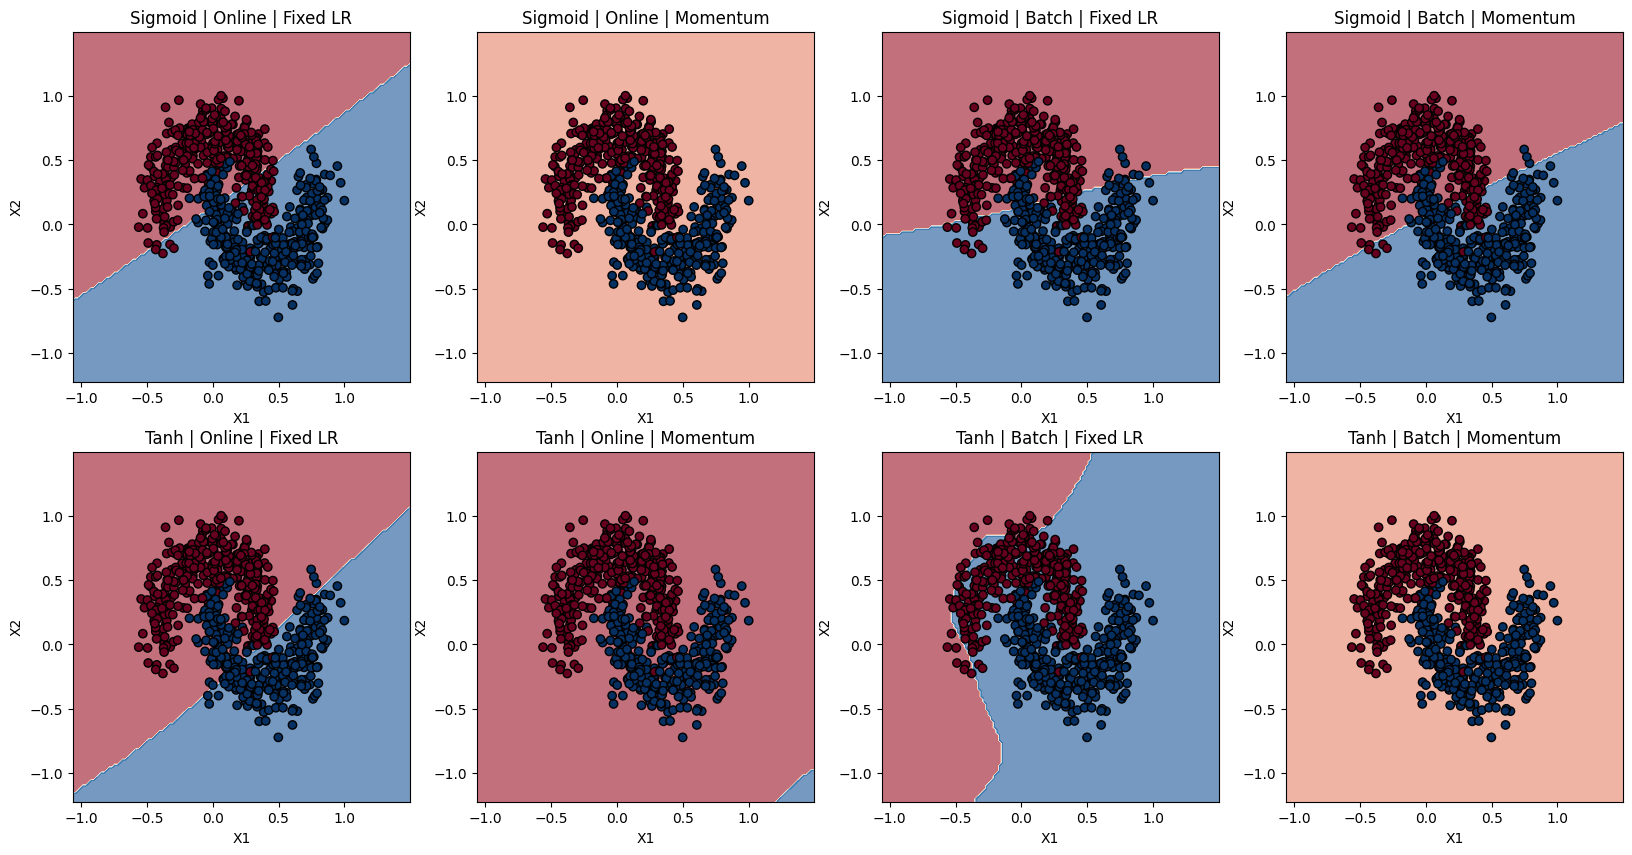

In [6]:
from itertools import product
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, weights, activation, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_bias = np.concatenate((grid, np.ones((grid.shape[0], 1))), axis=1)
    def model(X):
        for i, w in enumerate(weights):
            act = sigmoid if activation == 'sigmoid' or i == len(weights)-1 else tanh
            X = act(X @ w)
        return X

    Z = model(grid_bias)
    Z = (Z >= 0.5).astype(int).reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')

results = []

configs = list(product(['sigmoid', 'tanh'], [1, len(x_train)], [0.0, 0.9]))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (act, batch_size, momentum_value) in enumerate(configs):
    weights, _ = train_mlp(x_train, y_train, x_test, y_test,
        num_layers=2, hidden_size=64, batch_size=batch_size,
        epochs=30, lr=0.5, activation_name=act, momentum=momentum_value)

    # evaluate and print accuracy
    X_test_bias = np.concatenate((x_test, np.ones((x_test.shape[0], 1))), axis=1)
    test_acc = evaluate(X_test_bias, y_test, weights)
    mode = 'Online' if batch_size == 1 else 'Batch'
    opt = 'Momentum' if momentum_value > 0 else 'Fixed LR'
    results.append((act, mode, opt, test_acc))

    ax = axes[i // 4, i % 4]
    plt.sca(ax)
    mode = 'Online' if batch_size == 1 else 'Batch'
    opt = 'Momentum' if momentum_value > 0 else 'Fixed LR'
    title = f"{act.capitalize()} | {mode} | {opt}"
    plot_decision_boundary(x_train, y_train, weights, act, title)


In [7]:
for act, mode, opt, acc in results:
    print(f"{act.capitalize():<7} | {mode:<6} | {opt:<10} | Accuracy: {acc:.3f}")

Sigmoid | Online | Fixed LR   | Accuracy: 0.815
Sigmoid | Online | Momentum   | Accuracy: 0.510
Sigmoid | Batch  | Fixed LR   | Accuracy: 0.810
Sigmoid | Batch  | Momentum   | Accuracy: 0.825
Tanh    | Online | Fixed LR   | Accuracy: 0.795
Tanh    | Online | Momentum   | Accuracy: 0.490
Tanh    | Batch  | Fixed LR   | Accuracy: 0.490
Tanh    | Batch  | Momentum   | Accuracy: 0.480


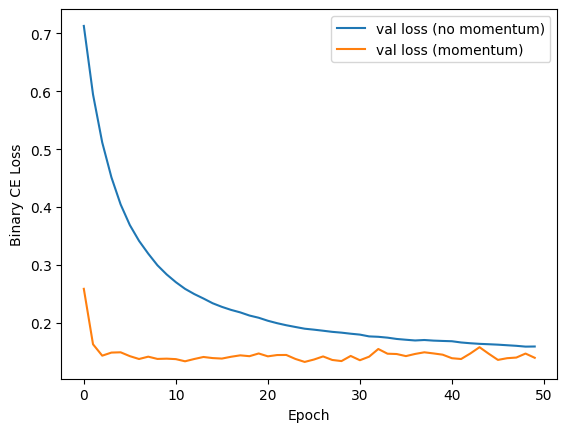

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(h):
    return h * (1 - h)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(h):
    return 1 - h ** 2

def binary_cross_entropy(pred, target):
    eps = 1e-8
    pred = np.clip(pred, eps, 1 - eps)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred)).mean()

def accuracy(pred, target):
    return ((pred >= 0.5).astype(int) == target).mean()

def initialize_weights(layer_dims):
    return [np.random.uniform(-1, 1, size=(layer_dims[i], layer_dims[i + 1])) for i in range(len(layer_dims) - 1)]

def back_propagate(activations, weights, targets, learning_rate, activation_derivative):
    output = activations[-1]
    delta = (output - targets) * activation_derivative(output)
    for i in reversed(range(len(weights))):
        dw = activations[i].T @ delta / len(targets)
        weights[i] -= learning_rate * dw
        if i != 0:
            delta = (delta @ weights[i].T) * activation_derivative(activations[i])
    return weights

def back_propagate_momentum(activations, weights, targets, learning_rate, activation_derivative, velocities, momentum):
    output = activations[-1]
    delta = (output - targets) * activation_derivative(output)
    for i in reversed(range(len(weights))):
        dw = activations[i].T @ delta / len(targets)
        velocities[i] = momentum * velocities[i] + dw
        weights[i] -= learning_rate * velocities[i]
        if i != 0:
            delta = (delta @ weights[i].T) * activation_derivative(activations[i])
    return weights, velocities

def feed_forward(input_data, weights, activation):
    activations = [input_data]
    for w in weights:
        input_data = activation(input_data @ w)
        activations.append(input_data)
    return activations

def train_mlp(X_train, y_train, X_val, y_val, num_layers=1, hidden_size=16, batch_size=16,
              epochs=50, lr=0.5, activation_name='sigmoid', patience=10, momentum=0.0):
    X_train = np.concatenate((X_train, np.ones((X_train.shape[0], 1))), axis=1)
    y_train = y_train.reshape(-1, 1)
    X_val = np.concatenate((X_val, np.ones((X_val.shape[0], 1))), axis=1)
    y_val = y_val.reshape(-1, 1)
    activ_func = sigmoid if activation_name == 'sigmoid' else tanh
    deriv_func = sigmoid_derivative if activation_name == 'sigmoid' else tanh_derivative
    layer_dims = [X_train.shape[1]] + [hidden_size] * num_layers + [1]
    weights = initialize_weights(layer_dims)
    velocities = [np.zeros_like(w) for w in weights] if momentum > 0 else None
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        perm = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]
        batch_losses = []
        for i in range(0, len(X_train), batch_size):
            Xb = X_train_shuffled[i:i+batch_size]
            yb = y_train_shuffled[i:i+batch_size]
            activs = feed_forward(Xb, weights, activ_func)
            if momentum > 0:
                weights, velocities = back_propagate_momentum(activs, weights, yb, lr, deriv_func, velocities, momentum)
            else:
                weights = back_propagate(activs, weights, yb, lr, deriv_func)
            batch_losses.append(binary_cross_entropy(activs[-1], yb))
        train_losses.append(np.mean(batch_losses))
        val_acts = feed_forward(X_val, weights, activ_func)
        val_losses.append(binary_cross_entropy(val_acts[-1], y_val))
    return train_losses, val_losses

np.random.seed(1)
n = 200
X0 = np.random.randn(n//2, 2) + np.array([-1,-1])
X1 = np.random.randn(n//2, 2) + np.array([1,1])
X = np.vstack((X0, X1))
y = np.array([0]*(n//2) + [1]*(n//2))
idx = np.random.permutation(n)
train_idx, val_idx = idx[:150], idx[150:]
X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

train_no_m, val_no_m = train_mlp(X_train, y_train, X_val, y_val, epochs=50, lr=0.5, activation_name='sigmoid', momentum=0.0)
train_mom, val_mom = train_mlp(X_train, y_train, X_val, y_val, epochs=50, lr=0.5, activation_name='sigmoid', momentum=0.9)

plt.plot(val_no_m, label='val loss (no momentum)')
plt.plot(val_mom, label='val loss (momentum)')
plt.xlabel('Epoch')
plt.ylabel('Binary CE Loss')
plt.legend()
plt.show()


**این بخش مربوط به کدهای تستی است برای مشاهده نتایج **

In [ ]:
weights_sigmoid, history_sigmoid = train_mlp(x_train, y_train, x_test, y_test, num_layers=2, hidden_size=64, batch_size=16, epochs=30, lr=0.5, activation_name='sigmoid')
weights_tanh, history_tanh = train_mlp(x_train, y_train, x_test, y_test, num_layers=2, hidden_size=64, batch_size=16, epochs=30, lr=0.5, activation_name='tanh')
test_acc_sig = evaluate(np.concatenate((x_test, np.ones((x_test.shape[0], 1))), axis=1), y_test, weights_sigmoid)
test_acc_tanh = evaluate(np.concatenate((x_test, np.ones((x_test.shape[0], 1))), axis=1), y_test, weights_tanh)
print(f"Sigmoid Test Accuracy: {test_acc_sig:.3f}")
print(f"Tanh Test Accuracy: {test_acc_tanh:.3f}")

In [ ]:
weights_sigmoid, history_sigmoid = train_mlp(x_train, y_train, x_test, y_test, num_layers=2, hidden_size=64, batch_size=1, epochs=30, lr=0.5, activation_name='sigmoid')
weights_tanh, history_tanh = train_mlp(x_train, y_train, x_test, y_test, num_layers=2, hidden_size=64, batch_size=1, epochs=30, lr=0.5, activation_name='tanh')
test_acc_sig = evaluate(np.concatenate((x_test, np.ones((x_test.shape[0], 1))), axis=1), y_test, weights_sigmoid)
test_acc_tanh = evaluate(np.concatenate((x_test, np.ones((x_test.shape[0], 1))), axis=1), y_test, weights_tanh)
print(f"Sigmoid Test Accuracy: {test_acc_sig:.3f}")
print(f"Tanh Test Accuracy: {test_acc_tanh:.3f}")

In [ ]:
weights_sigmoid, history_sigmoid = train_mlp(x_train, y_train, x_test, y_test, num_layers=2, hidden_size=64, batch_size=1, epochs=30, lr=0.5, activation_name='sigmoid', momentum=0.5)
test_acc_sig = evaluate(np.concatenate((x_test, np.ones((x_test.shape[0], 1))), axis=1), y_test, weights_sigmoid)
print(f"Sigmoid Test Accuracy: {test_acc_sig:.3f}")